<a href="https://colab.research.google.com/github/Hamzakh786/Stock-Price-Prediction-Using-LSTM/blob/main/StockPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from tensorflow import keras
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

In [3]:
#Load the data
data = pd.read_csv("/content/MSFT.csv")
print(data.head())
print(data.info())
print(data.describe())

         Date      Open      High       Low     Close  Adj Close      Volume
0  1986-03-13  0.088542  0.101563  0.088542  0.097222   0.061434  1031788800
1  1986-03-14  0.097222  0.102431  0.097222  0.100694   0.063628   308160000
2  1986-03-17  0.100694  0.103299  0.100694  0.102431   0.064725   133171200
3  1986-03-18  0.102431  0.103299  0.098958  0.099826   0.063079    67766400
4  1986-03-19  0.099826  0.100694  0.097222  0.098090   0.061982    47894400
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9083 entries, 0 to 9082
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9083 non-null   object 
 1   Open       9083 non-null   float64
 2   High       9083 non-null   float64
 3   Low        9083 non-null   float64
 4   Close      9083 non-null   float64
 5   Adj Close  9083 non-null   float64
 6   Volume     9083 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 496.9+ KB
None
   

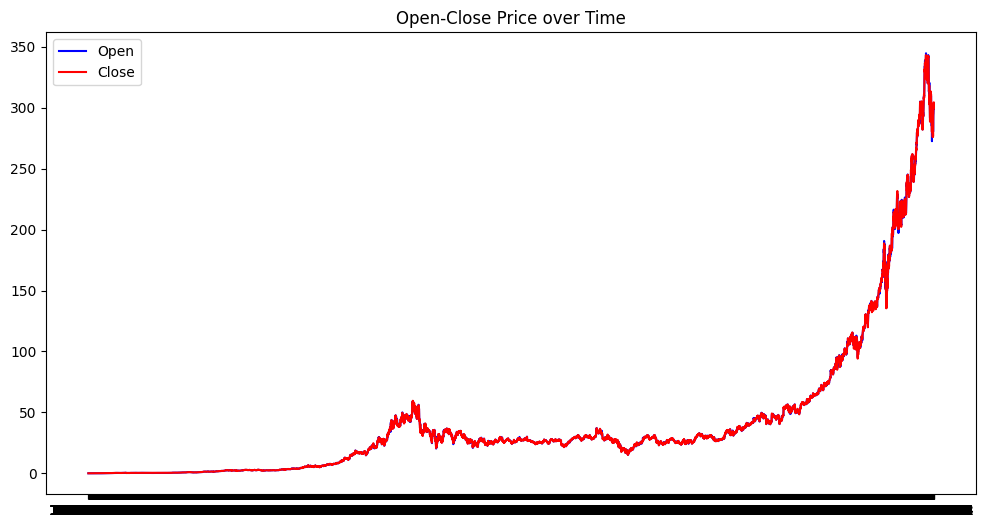

In [7]:
# Initial Data Visualization
# Plot 1 - Open and Close Prices of time
plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Open'], label="Open",color="blue")
plt.plot(data['Date'], data['Close'], label="Close",color="red")
plt.title("Open-Close Price over Time")
plt.legend()
# plt.show()

Text(0.5, 1.0, 'Stock Volume over Time')

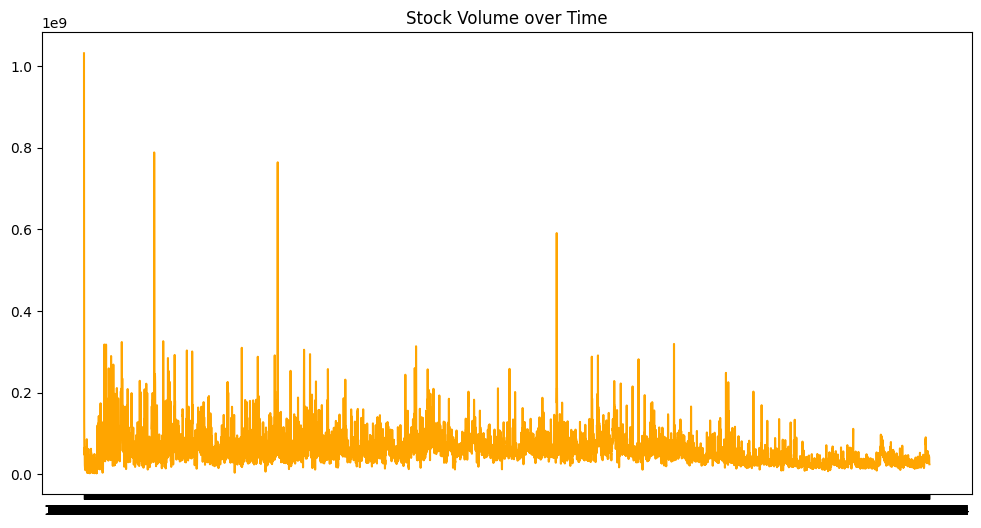

In [9]:

# Plot 2 - Trading Volume (check for outliers)
plt.figure(figsize=(12,6))
plt.plot(data['Date'],data['Volume'],label="Volume",color="orange")
plt.title("Stock Volume over Time")
# plt.show()

In [10]:
#Drop non numerical data
numeric_data = data.select_dtypes(include=["int64","float64"])

Text(0.5, 1.0, 'Feature Correlation Heatmap')

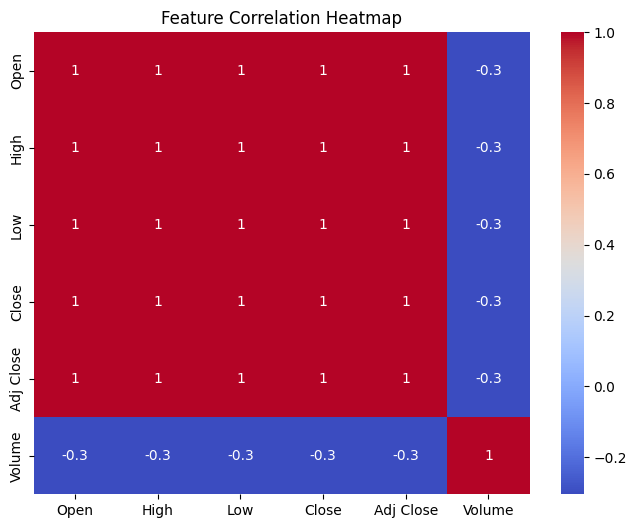

In [11]:
# Plot 3 - Check for correlation between features
plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
# plt.show()

In [14]:
#Conevert the Data into Datatime then create date filter
data['Date'] = pd.to_datetime(data['Date'])

In [15]:
# Convert the Data into Date time then create a date filter

prediction = data.loc[
    (data['Date'] > datetime(2013,1,1)) &
    (data['Date'] < datetime(2024,1,1))
]

Text(0.5, 1.0, 'Price over time')

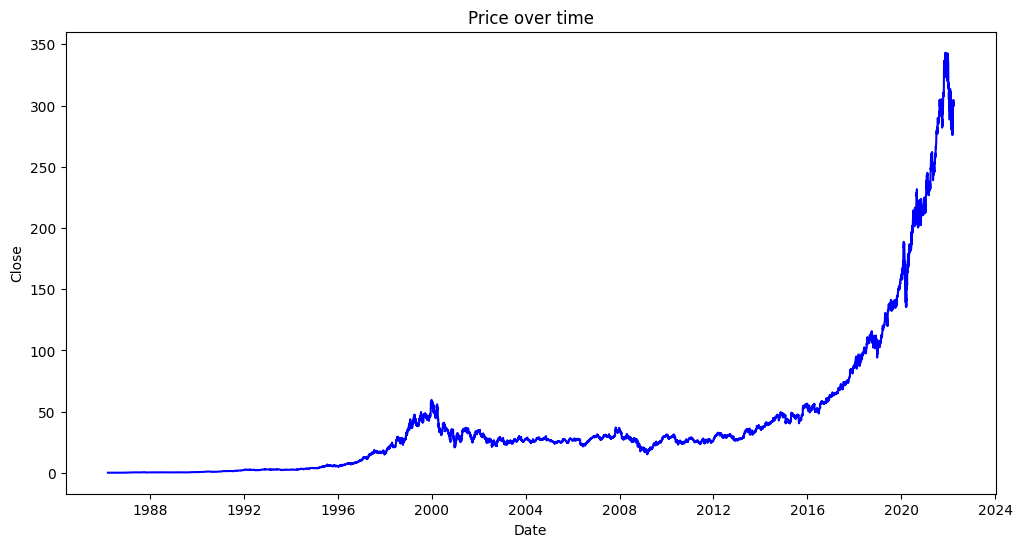

In [17]:
plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Close'],color="blue")
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Price over time")

In [20]:
# Prepare for the LSTM Model (Sequential)
stock_close = data.filter(["Close"])
dataset = stock_close.values #convert to numpy array
training_data_len = int(np.ceil(len(dataset) * 0.95))

In [21]:
# Preprocessing Stages
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

training_data = scaled_data[:training_data_len] #95% of all out data

X_train, y_train = [], []

In [22]:

# Create a sliding window for our stock (60 days)
for i in range(60, len(training_data)):
    X_train.append(training_data[i-60:i, 0])
    y_train.append(training_data[i,0])

X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))


In [23]:
# Build the Model
model = keras.models.Sequential()

# First Layer
model.add(keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1],1)))

# Second Layer
model.add(keras.layers.LSTM(64, return_sequences=False))

# 3rd Layer (Dense)
model.add(keras.layers.Dense(128, activation="relu"))

# 4th Layer (Dropout) to prevent overfitting
model.add(keras.layers.Dropout(0.5))

# Final Output Layer
model.add(keras.layers.Dense(1))

model.summary()
model.compile(optimizer="adam",
              loss="mae",
              metrics=[keras.metrics.RootMeanSquaredError()])


training = model.fit(X_train, y_train, epochs=20, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0718 - root_mean_squared_error: 0.1345
Epoch 2/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0533 - root_mean_squared_error: 0.0849
Epoch 3/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0486 - root_mean_squared_error: 0.0805
Epoch 4/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0470 - root_mean_squared_error: 0.0802
Epoch 5/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0460 - root_mean_squared_error: 0.0815
Epoch 6/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0444 - root_mean_squared_error: 0.0803
Epoch 7/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0420 - root_mean_squared_error: 0.0745
Epoch 8/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0415 - root_mean_squared_error: 0.0752
Epoch 9/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0416 - root_mean_squared_error: 0.0774
Epoch 10/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0423 - root_mean_squared_

In [24]:
# Prep the test data
test_data = scaled_data[training_data_len - 60:]
X_test, y_test = [], dataset[training_data_len:]


for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1 ))


In [25]:
# Make a Prediction
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions) #This converts the scaled predictions back to the original units.

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


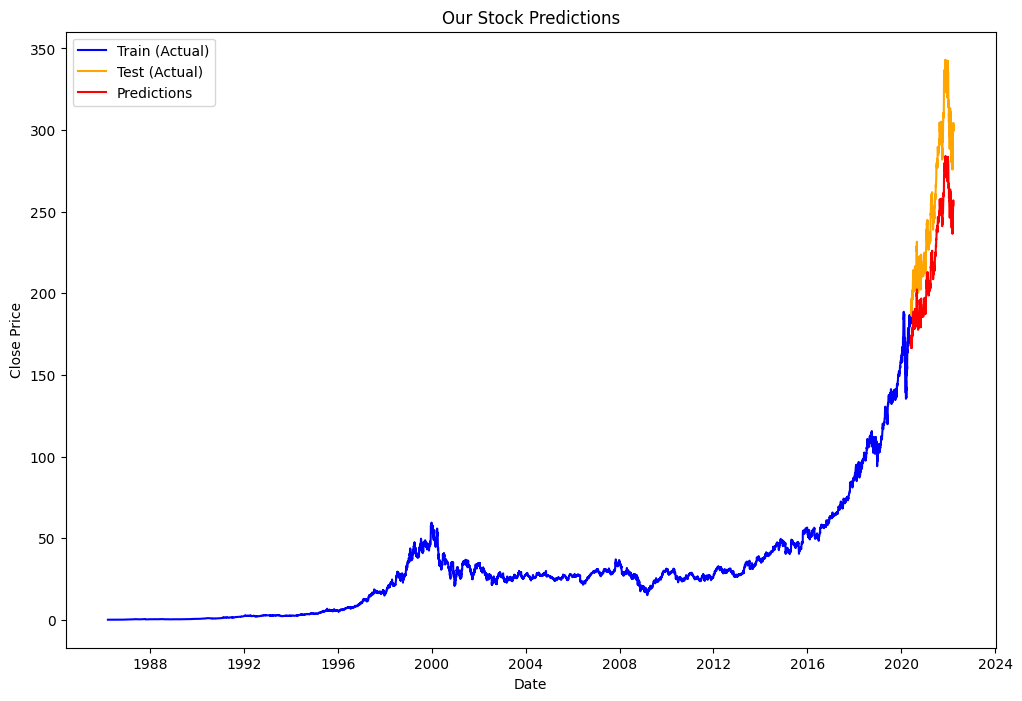

In [26]:
# Plotting data
train = data[:training_data_len]
test =  data[training_data_len:]

test = test.copy()

test['Predictions'] = predictions

plt.figure(figsize=(12,8))
plt.plot(train['Date'], train['Close'], label="Train (Actual)", color='blue')
plt.plot(test['Date'], test['Close'], label="Test (Actual)", color='orange')
plt.plot(test['Date'], test['Predictions'], label="Predictions", color='red')
plt.title("Our Stock Predictions")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 36.04635162107439
RMSE: 37.76835831256986
